# Fake News Detection using NLP

This notebook treats fake news detection as a comparative study, not a single-model exercise. It walks through three text representations and four models side by side, then checks whether handcrafted features actually help before trusting them.

In [1]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

## Loading the Data

In [4]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

In [5]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.",News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before th

In [6]:
true_df.head()


title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [7]:
fake_df.shape

(23481, 4)

In [8]:
true_df.shape

(21417, 4)

In [9]:
23481 + 21417

44898

In [10]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [11]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [12]:
fake_df["subject"].value_counts()

,count
subject,
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [13]:
true_df["subject"].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145


Fake has 23,481 rows and True has 21,417, close enough to call balanced. Fake spans six subject categories while True has only two, and that split lines up closely with the label itself. That is exactly why `subject` gets dropped as a leakage risk further down.

## Assigning Labels

In [14]:
fake_df["label"] = 0
true_df["label"] = 1

## Merge & Shuffle

In [15]:
df = pd.concat([fake_df, true_df], ignore_index=True)
df.shape

(44898, 5)

In [16]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


In [17]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [18]:
df.head()

title  \
0  Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution   
1                                    Trump drops Steve Bannon from National Security Council   
2                           Puerto Rico expects U.S. to lift Jones Act shipping restrictions   
3   OOPS: Trump Just Accidentally Confirmed He Leaked Israeli Intelligence To Russia (VIDEO)   
4                                    Donald Trump heads for Scotland to reopen a golf resort   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [19]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [20]:
# Save the Raw Dataset to a CSV file
df.to_csv('Raw_Dataset.csv', index=False)

## Label Balance

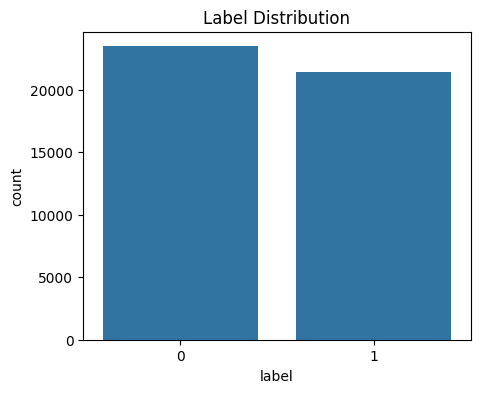

In [21]:
plt.figure(figsize=(5,4))

sns.countplot(x="label", data=df)

plt.title("Label Distribution")
plt.show()

The plot confirms the same 52/48 split seen earlier. That is close enough to balanced, so none of the models below need class weighting or oversampling.

## Dropping Leakage Columns

In [22]:
df.drop(columns=["subject", "date"], inplace=True)
df.columns

Index(['title', 'text', 'label'], dtype='object')

`subject` is dropped for the reason flagged earlier. It tracks which source file a row came from almost as well as the label does, so keeping it would let a model shortcut the real task. `date` adds no content signal either, so it goes too.

In [23]:
df.isnull().sum()

,0
title,0
text,0
label,0


Zero missing values in any remaining column, so there is nothing to fill in before moving on.

In [24]:
df.duplicated().sum()

np.int64(5793)

5,793 fully duplicated rows show up here, almost 13% of the merged dataset. If any of these end up split across train and test, the model would effectively be tested on rows it already saw during training.

## Empty Text Check

In [25]:
(df["text"].str.strip() == "").sum()

np.int64(631)

631 articles have a blank `text` field but still carry a real title. Dropping these rows would throw away that title information, which is why title and text get combined next instead of dropped.

In [26]:
df["text_length"] = df["text"].apply(len)

df["text_length"].describe()

,text_length
count,44898.000000
mean,2469.109693
std,2171.617091
min,1.000000
25%,1234.000000
50%,2186.000000
75%,3105.000000
max,51794.000000


In [27]:
df[df["text_length"] <= 5][["title", "text", "label"]]

,title,text,label
11,WHERE’S HILLARY? CLINTON SPOTTED Dining Alone,,0
41,WHOA! RUSH LIMBAUGH RIPS Into Republicans Who Don’t Support Trump [Audio],,0
177,HILLARY TAKES CREDIT For The Arab Spring Disaster…AND SHE WANTS TO BE PRESIDENT?,,0
324,CHILLING! FOX REPORTER JAMES ROSEN Recounts Being Spied on by the Obama Mafia [Video],,0
400,LIVE FEED: INAUGURATION 2017!,,0
...,...,...,...
44530,"TRUMP ANNOUNCES Two More Companies Join “America First” Job’s Campaign…8,000 JOBS! [VIDEO]",,0
44782,TUCKER CARLSON Defends Trump On Sweden Comment That The Left Went Nuts Over! [Video],,0
44868,AWESOME! HISPANIC TRUMP SUPPORTER Rips Into Pro-Sanctuary City Officials: “I’m a hard core TRUMP supporter” [Video],,0
44878,DEMOCRAT OPERATIVES Caught Planning To Bully Women At Trump Rally [Video],,0


In [28]:
df[df["text_length"] <= 5]["text"].value_counts()

,count
text,
,627
,4
Ouch!,2


Most of the rows with 5 characters or less of body text are empty strings (627 of them), with a few one-word placeholders like "Ouch!" mixed in. This looks like scraping noise, not a labeling problem, and combining title and text covers most of the gap without needing separate handling.

## Combining Title + Text

In [29]:
df["content"] = df["title"] + " " + df["text"]

Headlines often carry sharper signals than body text, things like sensational phrasing or loaded claims. Folding title into content keeps that signal available to every vectorizer used later, instead of losing it.

## Removing Duplicates

In [30]:
df[df.duplicated()].head(10)

title  \
1043                    CHILLING PHOTO Captures FEMALE SUICIDE BOMBER Carrying Baby Moments Before She Blows Both Of Them Up   
1158                 TEEN VOGUE Publishes Article To Teach Teen Girls How To Have Anal Sex: “ANAL 101, for teens, beginners”   
1343                                        THOUGHT POLICE: US Border Control Wants to Study Your Facebook, Twitter Accounts   
1366  WATCH: BLACK SPORTS HOST BLASTS White ESPN Sports Host For Asking White Athletes To Take A Knee During National Anthem   
1371                  LOL! This One Picture Sums Up Trump’s BRUTAL SMACKDOWN Of Mainstream Media At Today’s Press Conference   
1402                                       Hillary Clinton is ‘Most Corrupt, Militaristic Candidate We Have Seen in Decades’   
1405                                                                    HA! YOU WON’T BELIEVE HILLARY’S LUXURY “SCOOBY” VAN!   
1425                                                                         HACKED! COMMIE GEORGE SOROS Hacked By DC Leaks!   
1631                  ‘Who Appointed You to the Supreme Court?’: Senator DESTROYS Yates For Defying Trump Travel Ban [Video]   
1655                                 BREAKING EMAIL LEAK: “Bernie needs to be ground to a pulp…Crush him as hard as you can”   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [31]:
df.drop_duplicates(inplace=True)

This clears out the 5,793 duplicates flagged earlier. Removing them before the train/test split is what actually prevents leakage, since a duplicate split across both sides would let the model be evaluated on something it already saw during training.

## Dropping Original Columns

In [32]:
df.drop(columns=["title", "text"], inplace=True)

In [33]:
df.head()

label  text_length  \
0      0         1028   
1      1         4820   
2      1         1848   
3      0         1244   
4      1         3137   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [34]:
df.drop(columns=["text_length"], inplace=True)

In [35]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

In [36]:
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## Lowercasing

In [37]:
df["clean_content"] = df["content"].str.lower()

In [38]:
df[["content", "clean_content"]].head(3)

content  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and f

## Exclamation Count

In [39]:
df["exclamation_count"] = df["clean_content"].str.count("!")


In [40]:
df["exclamation_count"].value_counts()

,count
exclamation_count,
0,31562
1,3934
2,1685
3,824
4,405
5,234
6,154
7,95
8,74


In [41]:
df.groupby("label")["exclamation_count"].mean()

,exclamation_count
label,
0,0.854813
1,0.063028


Fake articles average 0.85 exclamation marks each, against 0.06 for True, roughly 13 times more. That gap is large enough to carry forward as its own numeric feature instead of leaving it buried inside the TF-IDF vocabulary.

## Text Length Feature

In [42]:
df["text_length"] = df["clean_content"].apply(len)

In [43]:
df.groupby("label")["text_length"].mean()

,text_length
label,
0,2578.704601
1,2444.356277


In [44]:
df.groupby("label")["text_length"].median()

,text_length
label,
0,2292.0
1,2282.0


Mean length runs 2,579 characters for Fake against 2,444 for True, and the medians (2,292 vs 2,282) sit even closer together. Length separates the two classes far less cleanly than exclamation marks do, so it is still worth keeping as a feature, just with modest expectations.

## URL Detection

In [45]:
df["clean_content"] = df["clean_content"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x)
)

In [46]:
df[
    df["content"].str.contains("http|www", case=False, na=False)
][["content", "clean_content", "label"]].head()

content  \
3                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         OOPS: Trump Just Accidentally Confirmed He Leaked Israeli Intelligence To Russia (VIDEO) On Monday, Donald Trump once again embarrassed himself and his country by accidentally revealing the source of the extremely classified information he leaked to Russia earlier this month.While it was speculated that the source of the information was Israel, Trump made things crystal clear during a press conference with Prime Minister Benjamin Netanyahu. President Pussygrabber explained that he never   not once   said  Israel  duri

In [47]:
df["has_url"] = df["content"].str.contains(
    r"http|www",
    case=False,
    regex=True
)

In [48]:
df.groupby("label")["has_url"].mean()

,has_url
label,
0,0.142953
1,0.001981


14.3% of Fake articles contain a raw URL against 0.2% of True, the widest gap of the three engineered signals checked so far. Only `exclamation_count` and `text_length` end up in the enhanced feature set further down, so this signal is measured here but has not been used yet.

## URL Normalization

Links get collapsed into a single `url` token instead of keeping the raw domain. This keeps the vocabulary from filling up with one-off URLs that would not generalize past this dataset.

In [49]:
df["clean_content"] = df["content"].str.lower()

In [50]:
df["clean_content"] = df["clean_content"].apply(
    lambda x: re.sub(r"http\S+|www\S+", " url ", x)
)

## HTML Tag Removal

In [51]:
df["clean_content"].str.contains(r"<.*?>", regex=True).sum()

np.int64(68)

In [52]:
df["clean_content"] = df["clean_content"].apply(
    lambda x: re.sub(r"<.*?>", " ", x)
)

In [53]:
df["clean_content"].str.contains(r"<.*?>", regex=True).sum()

np.int64(0)

68 articles had leftover HTML tags before this step, zero after. The regex caught all of them on the first pass.

## Punctuation Removal

In [54]:
import string

df["clean_content"] = df["clean_content"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)

## Whitespace Cleanup

In [55]:
df["clean_content"] = (
    df["clean_content"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [56]:
multiple_spaces = df["clean_content"].str.contains(r"\s{2,}", regex=True).sum()

print(f"Rows with multiple spaces remaining: {multiple_spaces}")

Rows with multiple spaces remaining: 0


Zero rows with doubled-up spaces remain, so the collapse-and-strip step cleaned the whole corpus in one pass.

## Tokenization

In [57]:
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [58]:
from nltk.tokenize import word_tokenize

df["clean_content"] = df["clean_content"].apply(word_tokenize)

In [59]:
print(df["clean_content"].iloc[0])
print(type(df["clean_content"].iloc[0]))

['ben', 'stein', 'calls', 'out', '9th', 'circuit', 'court', 'committed', 'a', '‘', 'coup', 'd', '’', 'état', '’', 'against', 'the', 'constitution', '21st', 'century', 'wire', 'says', 'ben', 'stein', 'reputable', 'professor', 'from', 'pepperdine', 'university', 'also', 'of', 'some', 'hollywood', 'fame', 'appearing', 'in', 'tv', 'shows', 'and', 'films', 'such', 'as', 'ferris', 'bueller', 's', 'day', 'off', 'made', 'some', 'provocative', 'statements', 'on', 'judge', 'jeanine', 'pirro', 's', 'show', 'recently', 'while', 'discussing', 'the', 'halt', 'that', 'was', 'imposed', 'on', 'president', 'trump', 's', 'executive', 'order', 'on', 'travel', 'stein', 'referred', 'to', 'the', 'judgement', 'by', 'the', '9th', 'circuit', 'court', 'in', 'washington', 'state', 'as', 'a', 'coup', 'd', 'tat', 'against', 'the', 'executive', 'branch', 'and', 'against', 'the', 'constitution', 'stein', 'went', 'on', 'to', 'call', 'the', 'judges', 'in', 'seattle', 'political', 'puppets', 'and', 'the', 'judiciary', '

The printed tokens for the first article still include stray fragments, like the curly apostrophe sitting on its own and a lone `d` split out of "coup d'état." Punctuation removal ran before tokenization, so a few non-ASCII characters slipped through. This is harmless since stopword removal and stemming clean most of it up next.

## Stopword Removal

In [60]:
stopwords_set = set(stopwords.words("english"))

df["clean_content"] = df["clean_content"].apply(
    lambda x: [word for word in x if word not in stopwords_set]
)

print(df["clean_content"].iloc[0])

['ben', 'stein', 'calls', '9th', 'circuit', 'court', 'committed', '‘', 'coup', '’', 'état', '’', 'constitution', '21st', 'century', 'wire', 'says', 'ben', 'stein', 'reputable', 'professor', 'pepperdine', 'university', 'also', 'hollywood', 'fame', 'appearing', 'tv', 'shows', 'films', 'ferris', 'bueller', 'day', 'made', 'provocative', 'statements', 'judge', 'jeanine', 'pirro', 'show', 'recently', 'discussing', 'halt', 'imposed', 'president', 'trump', 'executive', 'order', 'travel', 'stein', 'referred', 'judgement', '9th', 'circuit', 'court', 'washington', 'state', 'coup', 'tat', 'executive', 'branch', 'constitution', 'stein', 'went', 'call', 'judges', 'seattle', 'political', 'puppets', 'judiciary', 'political', 'pawns', 'watch', 'interview', 'complete', 'statements', 'note', 'stark', 'contrast', 'rhetoric', 'leftist', 'media', 'pundits', 'neglect', 'note', 'court', 'ever', 'blocked', 'presidential', 'orders', 'immigration', 'past', 'discuss', 'legal', 'efficacy', 'halt', 'actual', 'text'

Comparing this list to the version above, connector words like "a," "the," "and," and "of" are gone. The words that actually carry meaning, like "stein," "trump," "court," and "constitution," all survive.

## Stemming

In [61]:
stemmer = PorterStemmer()

df["clean_content"] = df["clean_content"].apply(
    lambda x: [stemmer.stem(word) for word in x]
)

print(df["clean_content"].iloc[0])

['ben', 'stein', 'call', '9th', 'circuit', 'court', 'commit', '‘', 'coup', '’', 'état', '’', 'constitut', '21st', 'centuri', 'wire', 'say', 'ben', 'stein', 'reput', 'professor', 'pepperdin', 'univers', 'also', 'hollywood', 'fame', 'appear', 'tv', 'show', 'film', 'ferri', 'bueller', 'day', 'made', 'provoc', 'statement', 'judg', 'jeanin', 'pirro', 'show', 'recent', 'discuss', 'halt', 'impos', 'presid', 'trump', 'execut', 'order', 'travel', 'stein', 'refer', 'judgement', '9th', 'circuit', 'court', 'washington', 'state', 'coup', 'tat', 'execut', 'branch', 'constitut', 'stein', 'went', 'call', 'judg', 'seattl', 'polit', 'puppet', 'judiciari', 'polit', 'pawn', 'watch', 'interview', 'complet', 'statement', 'note', 'stark', 'contrast', 'rhetor', 'leftist', 'media', 'pundit', 'neglect', 'note', 'court', 'ever', 'block', 'presidenti', 'order', 'immigr', 'past', 'discuss', 'legal', 'efficaci', 'halt', 'actual', 'text', 'execut', 'orderread', 'trump', 'news', '21st', 'centuri', 'wire', 'trump', 'f

Some words collapse cleanly, like "committed" to "commit." Others turn into fragments that are not real English anymore, like "century" to "centuri" and "reputable" to "reput." This is the Porter stemmer being aggressive by design, and it explains why the top-words analysis further down sometimes shows odd-looking tokens instead of full words.

## Rejoining Tokens

In [62]:
df["clean_content"] = df["clean_content"].apply(lambda x: " ".join(x))

print(df["clean_content"].iloc[0])

ben stein call 9th circuit court commit ‘ coup ’ état ’ constitut 21st centuri wire say ben stein reput professor pepperdin univers also hollywood fame appear tv show film ferri bueller day made provoc statement judg jeanin pirro show recent discuss halt impos presid trump execut order travel stein refer judgement 9th circuit court washington state coup tat execut branch constitut stein went call judg seattl polit puppet judiciari polit pawn watch interview complet statement note stark contrast rhetor leftist media pundit neglect note court ever block presidenti order immigr past discuss legal efficaci halt actual text execut orderread trump news 21st centuri wire trump filessupport work subscrib becom member 21wiretv


## Saving Processed Data

In [63]:
# Select relevant columns for the final processed dataset
processed_df = df[['label', 'clean_content', 'exclamation_count', 'text_length']].copy()

# Save the processed DataFrame to a CSV file
processed_df.to_csv('processed_news_dataset.csv', index=False)

print("Final processed dataset saved to 'processed_news_dataset.csv'")

# Display the head of the saved dataset for confirmation
print("\nHead of the processed dataset:")
display(processed_df.head())

Final processed dataset saved to 'processed_news_dataset.csv'

Head of the processed dataset:


,label,clean_content,exclamation_count,text_length
0,0,ben stein call 9th circuit court commit ‘ coup ’ état ’ constitut 21st centuri wire say ben stein reput professor pepperdin univers also hollywood fame appear tv show film ferri bueller day made provoc statement judg jeanin pirro show recent discuss halt impos presid trump execut order travel stein refer judgement 9th circuit court washington state coup tat execut branch constitut stein went call judg seattl polit puppet judiciari polit pawn watch interview complet statement note stark contrast rhetor leftist media pundit neglect note court ever block presidenti order immigr past discuss legal efficaci halt actual text execut orderread trump news 21st centuri wire trump filessupport work subscrib becom member 21wiretv,0,1118
1,1,trump drop steve bannon nation secur council washington reuter us presid donald trump remov chief strategist steve bannon nation secur council wednesday revers controversi decis earli year give polit advis unpreced role secur discuss trump ’ overhaul nsc confirm white hous offici also elev gener joseph dunford chairman joint chief staff dan coat director nation intellig head 17 us intellig agenc offici said chang move nsc “ back core function ’ suppos ” also appear mark victori nation secur advis hr mcmaster told nation secur expert felt “ battl death ” bannon other white hous staff vice presid mike penc said bannon would continu play import role polici play shakeup routin “ natur evolut ensur nation secur council organ way best serv presid resolv make difficult decis ” penc said fox news bannon said statement succeed return nsc back tradit role coordin foreign polici rather run cite presid barack obama ’ nation secur advis susan rice advoc chang “ susan rice operation nsc last administr put nsc ensur ‘ deoperation ’ gener mcmaster nsc back proper function ” said trump ’ white hous team grappl infight intrigu hobbl young presid recent day sever senior us foreign polici nation secur offici said mechan shape trump administr ’ respons press challeng syria north korea iran still place critic bannon ’ role nsc said gave much weight decisionmak someon lack foreign polici expertis bannon chief execut trump ’ presidenti campaign month lead elect novemb respect repres trump ’ “ america first ” nationalist voic help fuel antiwashington fervor push presid part way time mainstream republican join trump administr bannon head breitbart news rightw websit us repres adam schiff rank democrat hous repres intellig committe call shift nsc posit step help mcmaster “ gain control bodi politic bannon ’ involv ” “ administr ’ polici north korea china russia syria continu drift hope shakeup bring level strateg vision bodi ” said bannon ’ remov nsc potenti setback sphere influenc trump white hous voic major decis trump confid said bannon remain influenti ever “ still involv everyth still full confid presid fair much stuff ” confid said speak condit anonym white hous offici said bannon longer need nsc departur trump ’ first nation secur advis michael flynn flynn forc resign feb 13 contact russia ’ ambassador unit state sergei kislyak prior trump take offic jan 20 offici said bannon place nsc origin check flynn attend one nsc ’ regular meet offici dismiss question power struggl bannon mcmaster say share world view howev two current nation secur offici reject white hous explan note two month pass sinc flynn ’ departur mcmaster said speak condit anonym also duel bannon other direct access trump futur deputi nation secur advis kt mcfarland former fox news comment intellig director ezra cohenwatnick flynn appointe staf decis trump prepar first facetofac meet thursday friday chines presid xi jinp threat north korea ’ nuclear missil program key compon talk bannon ’ seat nsc ’ “ princip ’ committe ” group includ secretari state defens rank aid taken rick perri energi secretari charg overse us nuclear weapon arsen,0,4876
2,1,puerto rico expect us lift jone act ship restrict reuter p

The saved file keeps `label`, `clean_content`, `exclamation_count`, and `text_length`. `has_url` is not included here since it is not used by any model in this notebook, only inspected during EDA above.

## Word Cloud

A quick visual check on the cleaned corpus. Larger words appear more often across all articles, fake and real combined, after stopword removal and stemming.

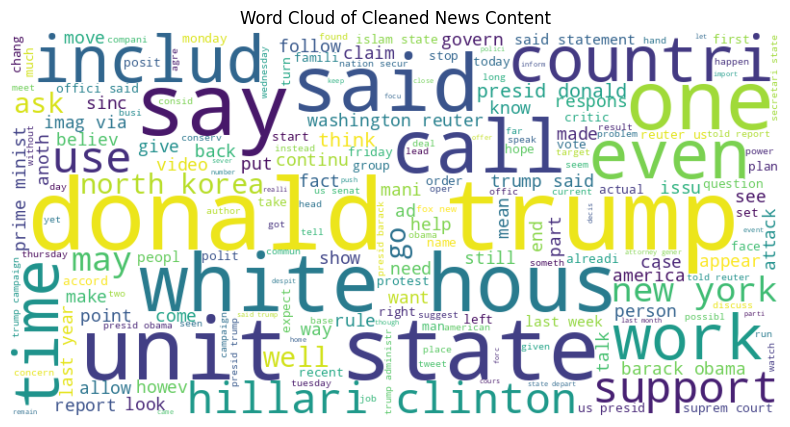

In [64]:
from wordcloud import WordCloud

all_words = ' '.join(df['clean_content'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned News Content')
plt.show()


Since the cloud is built from the full dataset with both labels mixed together, the biggest words are mostly generic news vocabulary, names, places, and common reporting verbs, not a fake-versus-real signal. Treat this as a sanity check that cleaning worked, with no leftover punctuation, HTML, or URLs crowding the plot. The **Top Words** section further down gives the actual label-specific signal.

## Bag-of-Words Vectorization

In [65]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(max_features=10000)
X_bow = count_vectorizer.fit_transform(df["clean_content"])

print(f"Shape of Bag-of-Words features: {X_bow.shape}")

Shape of Bag-of-Words features: (39105, 10000)


Bag-of-Words counts how often each word shows up, with no weight for how informative that word is. TF-IDF, in the next section, fixes that by down-weighting words that appear in almost every article. Both use the same vocabulary size of 10,000 features, so they are easy to compare.

In [66]:
bow_vocab = count_vectorizer.get_feature_names_out()
sample_row = X_bow[0].toarray().flatten()
top_word_ids = sample_row.argsort()[::-1][:10]

print("Top words by raw count in article 0:")
for word_id in top_word_ids:
    print(f"  {bow_vocab[word_id]:15s} count={sample_row[word_id]}")

Top words by raw count in article 0:
  stein           count=4
  trump           count=3
  execut          count=3
  court           count=3
  judg            count=2
  9th             count=2
  call            count=2
  circuit         count=2
  polit           count=2
  discuss         count=2


The top raw-count words for article 0 (stein, trump, execut, court, judg) line up with the named entities and legal vocabulary the article is actually about. Even without any weighting, a plain word count already captures what the article is mostly discussing.

## TF-IDF Vectorization

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=10000)  # Limiting features to manage dimensionality

X_tfidf = tfidf_vectorizer.fit_transform(df["clean_content"])
y = df["label"]

print(f"Shape of TF-IDF features: {X_tfidf.shape}")
print(f"Shape of labels: {y.shape}")

Shape of TF-IDF features: (39105, 10000)
Shape of labels: (39105,)


This has the same shape as Bag-of-Words, 10,000 features across the same row count. So any accuracy difference between the two later comes down to the weighting scheme, not a difference in vocabulary size.

## Word Embeddings (Word2Vec)

Bag-of-Words and TF-IDF both treat words as independent columns, so "government" and "administration" have no relationship in the feature space. Word2Vec learns a dense vector for each word from how words co-occur in this corpus, so similar words end up with similar vectors. This one is trained directly on the cleaned articles here, not loaded from outside pretrained vectors.

In [68]:
from gensim.models import Word2Vec

tokenized_content = df["clean_content"].str.split()

w2v_model = Word2Vec(
    sentences=tokenized_content,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"Vector size per word: {w2v_model.wv.vector_size}")

Vocabulary size: 71234
Vector size per word: 100


In [69]:
print("Words most similar to 'trump':")
for word, score in w2v_model.wv.most_similar("trump", topn=10):
    print(f"  {word:15s} similarity={score:.3f}")

Words most similar to 'trump':
  presidentelect  similarity=0.617
  obama           similarity=0.562
  ’               similarity=0.527
  republican      similarity=0.497
  “               similarity=0.491
  us              similarity=0.490
  bush            similarity=0.488
  trumpth         similarity=0.478
  presid          similarity=0.476
  trumptrump      similarity=0.472


The nearest neighbors to "trump" are presidentelect (0.617), obama (0.562), and republican, which are the words a person would expect to sit close to it in this corpus. That is a reasonable sanity check that the embedding space is capturing something meaningful before it gets used for classification.

To turn per-word vectors into one vector per article, the vectors of every word in that article get averaged. Words that never made it into the vocabulary, because they were too rare, are just skipped.

In [70]:
empty_vector_count = sum(
    1 for tokens in tokenized_content if not any(word in w2v_model.wv for word in tokens)
)

print(f"Articles with zero words in the Word2Vec vocabulary: {empty_vector_count}")

Articles with zero words in the Word2Vec vocabulary: 0


Every article has at least one word in the vocabulary, so the average above never needs a fallback. Straight averaging works for the whole dataset.

In [71]:
doc_vectors = [
    np.mean([w2v_model.wv[word] for word in tokens if word in w2v_model.wv], axis=0)
    for tokens in tokenized_content
]

X_embeddings = np.array(doc_vectors)
print(f"Shape of embedding features: {X_embeddings.shape}")

Shape of embedding features: (39105, 100)


**Three representations, side by side:**

| Representation | Dimensionality | What it captures |
|---|---|---|
| Bag-of-Words | 10,000 (sparse) | Raw word counts |
| TF-IDF | 10,000 (sparse) | Word counts, down-weighted by how common the word is across articles |
| Word2Vec (averaged) | 100 (dense) | Semantic similarity between words, learned from context |

The models later in this notebook train on the TF-IDF features, since that is the representation named in the baseline and enhanced comparisons. Bag-of-Words and the embeddings above are available here if you want to swap them in and compare.

## Train/Test Split

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (31284, 10000)
Shape of X_test: (7821, 10000)
Shape of y_train: (31284,)
Shape of y_test: (7821,)


31,284 rows go to training and 7,821 are held out for testing, an 80/20 split. It is stratified, so both sides keep the same roughly 52/48 Fake-to-True ratio as the full dataset.

## Model Training & Evaluation Setup

In [73]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Each model below is trained and evaluated in its own set of cells instead of a shared helper function. Fit the model, check train and test accuracy and the classification report, then plot the confusion matrix. It is more repetitive than a single function, but it is easier to see exactly what each model is doing.

## Baseline Models (TF-IDF Features Only)

In [74]:
results_baseline = []

### KNN (Non-Parametric)

In [75]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [76]:
knn_model_train_pred = knn_model.predict(X_train)
knn_model_test_pred = knn_model.predict(X_test)

knn_model_train_acc = accuracy_score(y_train, knn_model_train_pred)
knn_model_test_acc = accuracy_score(y_test, knn_model_test_pred)

print(f"Train Accuracy: {knn_model_train_acc:.4f}")
print(f"Test Accuracy: {knn_model_test_acc:.4f}")
print()
print(classification_report(y_test, knn_model_test_pred, target_names=["Fake", "True"]))

Train Accuracy: 0.9093
Test Accuracy: 0.8579

              precision    recall  f1-score   support

        Fake       0.93      0.75      0.83      3582
        True       0.82      0.95      0.88      4239

    accuracy                           0.86      7821
   macro avg       0.87      0.85      0.85      7821
weighted avg       0.87      0.86      0.86      7821



KNN's train and test accuracy sit 5 points apart (0.9093 vs 0.8579), the widest gap of any baseline model. Fake recall lands at only 0.75, meaning a quarter of actual fake articles get classified as True. Distance-based voting in a 10,000-dimensional sparse TF-IDF space does not separate the classes as cleanly as the other approaches below.

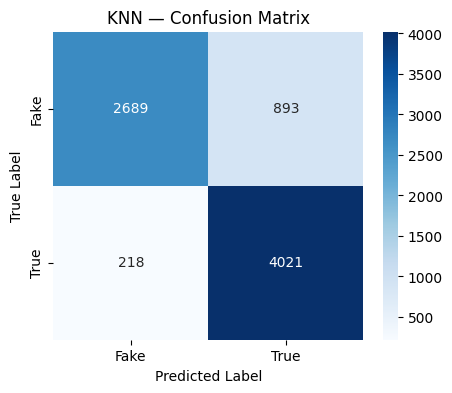

In [77]:
cm = confusion_matrix(y_test, knn_model_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("KNN — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [78]:
knn_model_report = classification_report(y_test, knn_model_test_pred, output_dict=True)

results_baseline.append({
    "Model": "KNN",
    "Train Accuracy": knn_model_train_acc,
    "Test Accuracy": knn_model_test_acc,
    "Precision (Fake)": knn_model_report["0"]["precision"],
    "Recall (Fake)": knn_model_report["0"]["recall"],
    "F1 (Fake)": knn_model_report["0"]["f1-score"],
    "Precision (True)": knn_model_report["1"]["precision"],
    "Recall (True)": knn_model_report["1"]["recall"],
    "F1 (True)": knn_model_report["1"]["f1-score"],
})

### Logistic Regression (Parametric)

In [79]:
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [80]:
log_reg_model_train_pred = log_reg_model.predict(X_train)
log_reg_model_test_pred = log_reg_model.predict(X_test)

log_reg_model_train_acc = accuracy_score(y_train, log_reg_model_train_pred)
log_reg_model_test_acc = accuracy_score(y_test, log_reg_model_test_pred)

print(f"Train Accuracy: {log_reg_model_train_acc:.4f}")
print(f"Test Accuracy: {log_reg_model_test_acc:.4f}")
print()
print(classification_report(y_test, log_reg_model_test_pred, target_names=["Fake", "True"]))

Train Accuracy: 0.9895
Test Accuracy: 0.9843

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      3582
        True       0.98      0.99      0.99      4239

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821



Train and test accuracy stay within half a point of each other (0.9895 vs 0.9843), and precision and recall both sit around 0.98 to 0.99 for each class. This is a genuinely balanced result, not one strong on Fake and weak on True or the other way around.

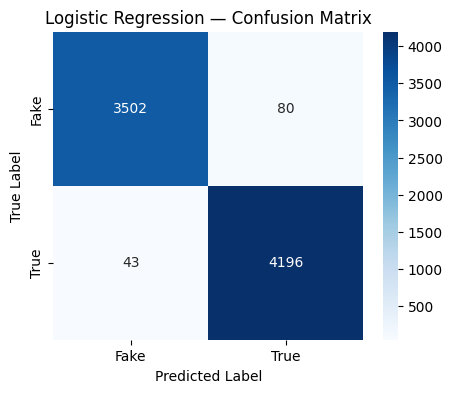

In [81]:
cm = confusion_matrix(y_test, log_reg_model_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [82]:
log_reg_model_report = classification_report(y_test, log_reg_model_test_pred, output_dict=True)

results_baseline.append({
    "Model": "Logistic Regression",
    "Train Accuracy": log_reg_model_train_acc,
    "Test Accuracy": log_reg_model_test_acc,
    "Precision (Fake)": log_reg_model_report["0"]["precision"],
    "Recall (Fake)": log_reg_model_report["0"]["recall"],
    "F1 (Fake)": log_reg_model_report["0"]["f1-score"],
    "Precision (True)": log_reg_model_report["1"]["precision"],
    "Recall (True)": log_reg_model_report["1"]["recall"],
    "F1 (True)": log_reg_model_report["1"]["f1-score"],
})

### Random Forest (Ensemble)

In [83]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [84]:
rf_model_train_pred = rf_model.predict(X_train)
rf_model_test_pred = rf_model.predict(X_test)

rf_model_train_acc = accuracy_score(y_train, rf_model_train_pred)
rf_model_test_acc = accuracy_score(y_test, rf_model_test_pred)

print(f"Train Accuracy: {rf_model_train_acc:.4f}")
print(f"Test Accuracy: {rf_model_test_acc:.4f}")
print()
print(classification_report(y_test, rf_model_test_pred, target_names=["Fake", "True"]))

Train Accuracy: 0.9817
Test Accuracy: 0.9720

              precision    recall  f1-score   support

        Fake       0.99      0.95      0.97      3582
        True       0.96      0.99      0.97      4239

    accuracy                           0.97      7821
   macro avg       0.97      0.97      0.97      7821
weighted avg       0.97      0.97      0.97      7821



Random Forest trades recall for precision on the Fake class: 0.99 precision but only 0.95 recall. It rarely misfires when it calls something fake, but it also lets more actual fake articles through than Logistic Regression does. The train-test gap (0.9817 vs 0.9720) stays tighter than KNN's, so `max_depth=10` is keeping the ensemble from memorizing the training set outright.

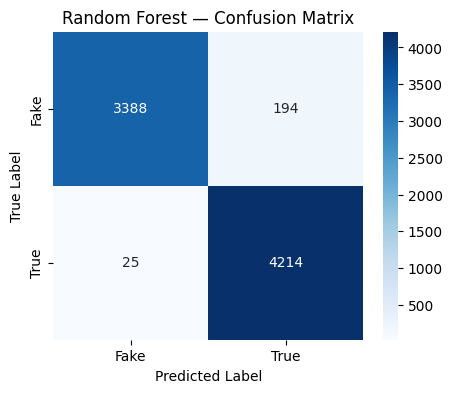

In [85]:
cm = confusion_matrix(y_test, rf_model_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [86]:
rf_model_report = classification_report(y_test, rf_model_test_pred, output_dict=True)

results_baseline.append({
    "Model": "Random Forest",
    "Train Accuracy": rf_model_train_acc,
    "Test Accuracy": rf_model_test_acc,
    "Precision (Fake)": rf_model_report["0"]["precision"],
    "Recall (Fake)": rf_model_report["0"]["recall"],
    "F1 (Fake)": rf_model_report["0"]["f1-score"],
    "Precision (True)": rf_model_report["1"]["precision"],
    "Recall (True)": rf_model_report["1"]["recall"],
    "F1 (True)": rf_model_report["1"]["f1-score"],
})

### Simple Neural Network (Deep Learning)

Kept small, one hidden layer with 50 units, so it stays quick to train and easy to explain.

In [87]:
nn_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=200, random_state=42)
nn_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(50,), random_state=42)

In [88]:
nn_model_train_pred = nn_model.predict(X_train)
nn_model_test_pred = nn_model.predict(X_test)

nn_model_train_acc = accuracy_score(y_train, nn_model_train_pred)
nn_model_test_acc = accuracy_score(y_test, nn_model_test_pred)

print(f"Train Accuracy: {nn_model_train_acc:.4f}")
print(f"Test Accuracy: {nn_model_test_acc:.4f}")
print()
print(classification_report(y_test, nn_model_test_pred, target_names=["Fake", "True"]))

Train Accuracy: 1.0000
Test Accuracy: 0.9875

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      3582
        True       0.99      0.99      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



Train accuracy hits a perfect 1.0000, a textbook sign of overfitting, yet test accuracy still holds at 0.9875, the highest of any baseline model. The network memorized the training set, but generalization barely suffers, most likely because Fake and True are separable enough in TF-IDF space that a memorized boundary still lines up well with unseen data.

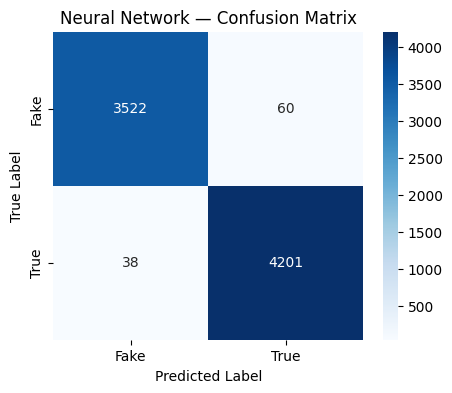

In [89]:
cm = confusion_matrix(y_test, nn_model_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("Neural Network — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [90]:
nn_model_report = classification_report(y_test, nn_model_test_pred, output_dict=True)

results_baseline.append({
    "Model": "Neural Network",
    "Train Accuracy": nn_model_train_acc,
    "Test Accuracy": nn_model_test_acc,
    "Precision (Fake)": nn_model_report["0"]["precision"],
    "Recall (Fake)": nn_model_report["0"]["recall"],
    "F1 (Fake)": nn_model_report["0"]["f1-score"],
    "Precision (True)": nn_model_report["1"]["precision"],
    "Recall (True)": nn_model_report["1"]["recall"],
    "F1 (True)": nn_model_report["1"]["f1-score"],
})

## Baseline Model Comparison

In [91]:
baseline_df = pd.DataFrame(results_baseline)
baseline_df


,Model,Train Accuracy,Test Accuracy,Precision (Fake),Recall (Fake),F1 (Fake),Precision (True),Recall (True),F1 (True)
0,KNN,0.909315,0.857947,0.925009,0.750698,0.828787,0.818274,0.948573,0.878619
1,Logistic Regression,0.989451,0.984273,0.987870,0.977666,0.982742,0.981291,0.989856,0.985555
2,Random Forest,0.981684,0.971998,0.992675,0.945840,0.968692,0.955989,0.994102,0.974673
3,Neural Network,1.000000,0.987470,0.989326,0.983250,0.986278,0.985919,0.991036,0.988471


Ranked by test accuracy: Neural Network (0.9875), Logistic Regression (0.9843), Random Forest (0.9720), then KNN well behind at 0.8579. The gap between the top three is under half a point, so the real story here is KNN's weakness, not a clear winner among the other three.

## Representation Comparison: Logistic Regression on Every Feature Set

In [92]:
results_representation = []

In [93]:
results_representation.append({
    "Model": "Logistic Regression (TF-IDF)",
    "Train Accuracy": log_reg_model_train_acc,
    "Test Accuracy": log_reg_model_test_acc,
    "F1 (Fake)": log_reg_model_report["0"]["f1-score"],
    "F1 (True)": log_reg_model_report["1"]["f1-score"],
})

### Bag-of-Words

In [94]:
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

In [95]:
log_reg_bow = LogisticRegression(max_iter=1000, random_state=42)
log_reg_bow.fit(X_train_bow, y_train_bow)

LogisticRegression(max_iter=1000, random_state=42)

In [96]:
log_reg_bow_train_pred = log_reg_bow.predict(X_train_bow)
log_reg_bow_test_pred = log_reg_bow.predict(X_test_bow)

log_reg_bow_train_acc = accuracy_score(y_train_bow, log_reg_bow_train_pred)
log_reg_bow_test_acc = accuracy_score(y_test_bow, log_reg_bow_test_pred)

print(f"Train Accuracy: {log_reg_bow_train_acc:.4f}")
print(f"Test Accuracy: {log_reg_bow_test_acc:.4f}")
print()
print(classification_report(y_test_bow, log_reg_bow_test_pred, target_names=["Fake", "True"]))

Train Accuracy: 1.0000
Test Accuracy: 0.9937

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3582
        True       0.99      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



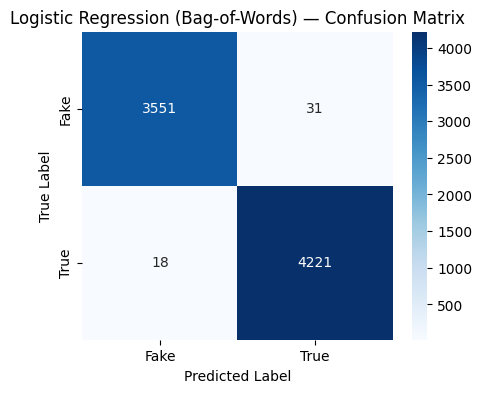

In [97]:
cm = confusion_matrix(y_test_bow, log_reg_bow_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("Logistic Regression (Bag-of-Words) — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [98]:
log_reg_bow_report = classification_report(y_test_bow, log_reg_bow_test_pred, output_dict=True)

results_representation.append({
    "Model": "Logistic Regression (Bag-of-Words)",
    "Train Accuracy": log_reg_bow_train_acc,
    "Test Accuracy": log_reg_bow_test_acc,
    "F1 (Fake)": log_reg_bow_report["0"]["f1-score"],
    "F1 (True)": log_reg_bow_report["1"]["f1-score"],
})

Bag-of-Words edges out TF-IDF here, 0.9937 test accuracy against 0.9843, despite being the simpler, unweighted representation. On a corpus with strong lexical tells like "reuter" and "said," raw counts separate the classes just as well as down-weighted ones, if not slightly better.

### Word2Vec Embeddings

In [99]:
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

In [100]:
log_reg_emb = LogisticRegression(max_iter=1000, random_state=42)
log_reg_emb.fit(X_train_emb, y_train_emb)

LogisticRegression(max_iter=1000, random_state=42)

In [101]:
log_reg_emb_train_pred = log_reg_emb.predict(X_train_emb)
log_reg_emb_test_pred = log_reg_emb.predict(X_test_emb)

log_reg_emb_train_acc = accuracy_score(y_train_emb, log_reg_emb_train_pred)
log_reg_emb_test_acc = accuracy_score(y_test_emb, log_reg_emb_test_pred)

print(f"Train Accuracy: {log_reg_emb_train_acc:.4f}")
print(f"Test Accuracy: {log_reg_emb_test_acc:.4f}")
print()
print(classification_report(y_test_emb, log_reg_emb_test_pred, target_names=["Fake", "True"]))

Train Accuracy: 0.9824
Test Accuracy: 0.9807

              precision    recall  f1-score   support

        Fake       0.98      0.98      0.98      3582
        True       0.98      0.98      0.98      4239

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821



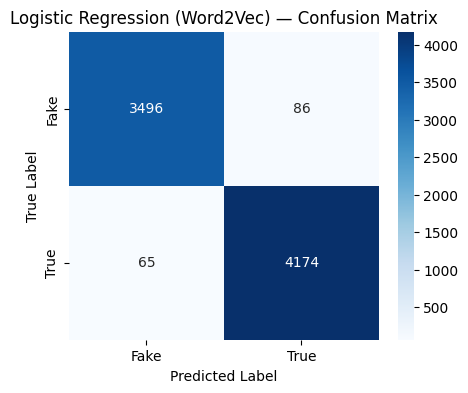

In [102]:
cm = confusion_matrix(y_test_emb, log_reg_emb_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("Logistic Regression (Word2Vec) — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [103]:
log_reg_emb_report = classification_report(y_test_emb, log_reg_emb_test_pred, output_dict=True)

results_representation.append({
    "Model": "Logistic Regression (Word2Vec)",
    "Train Accuracy": log_reg_emb_train_acc,
    "Test Accuracy": log_reg_emb_test_acc,
    "F1 (Fake)": log_reg_emb_report["0"]["f1-score"],
    "F1 (True)": log_reg_emb_report["1"]["f1-score"],
})

Even a compressed 100-dimensional averaged embedding, which trades exact word identity for semantic proximity, still reaches 0.9807 test accuracy, barely a point behind TF-IDF's 10,000 sparse dimensions. This suggests the split correlates strongly with topic and writing style, something a coarser semantic representation still picks up on.

### All Three Representations, Side by Side

In [104]:
representation_df = pd.DataFrame(results_representation)
representation_df

,Model,Train Accuracy,Test Accuracy,F1 (Fake),F1 (True)
0,Logistic Regression (TF-IDF),0.989451,0.984273,0.982742,0.985555
1,Logistic Regression (Bag-of-Words),1.000000,0.993735,0.993148,0.994229
2,Logistic Regression (Word2Vec),0.982387,0.980693,0.978860,0.982233


The final order, Bag-of-Words (0.9937), TF-IDF (0.9843), Word2Vec (0.9807), spans less than one point end to end. For this dataset, the choice of representation matters far less than expected, likely because Fake and True differ by vocabulary and topic more than by subtle meaning that only embeddings would catch.

## Top Words: Logistic Regression

Logistic Regression's coefficients show which TF-IDF terms push a prediction toward *Fake* (negative) or *True* (positive). This only works cleanly for a linear model like this one. There is no equivalent coefficient to inspect for KNN, Random Forest, or the neural net.

In [105]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = log_reg_model.coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})

top_true = coef_df.sort_values(by='coefficient', ascending=False).head(10)
top_fake = coef_df.sort_values(by='coefficient', ascending=True).head(10)

print("Top 10 words pushing toward 'True':\n")
print(top_true.to_string(index=False))

print("\nTop 10 words pushing toward 'Fake':\n")
print(top_fake.to_string(index=False))


Top 10 words pushing toward 'True':

   feature  coefficient
    reuter    21.747312
      said    18.635252
washington     6.184231
        us     5.503159
 wednesday     5.237847
   tuesday     4.950503
  thursday     4.772315
    friday     4.234860
    monday     4.140799
       nov     3.658772

Top 10 words pushing toward 'Fake':

 feature  coefficient
   video    -8.955481
    imag    -8.919171
     via    -8.668694
     gop    -5.728484
 hillari    -5.288624
    even    -4.654166
      mr    -4.475974
american    -4.042206
 america    -3.983274
     url    -3.799643


"reuter" carries the strongest coefficient on the True side at 21.7, ahead of "said" at 18.6. This is not evidence the model learned what makes reporting trustworthy. It is evidence that the True half of this dataset was sourced entirely from Reuters, so the model partly learned to recognize a wire-service byline instead. On the Fake side, "video," "imag," and "via" (around -8.7 to -9.0) point to sensational framing and embedded media links, a more generalizable signal than a single source name.

## Enhanced Models (TF-IDF + Handcrafted Features)

This adds `exclamation_count` and `text_length`, signals the baseline models above never see since they only look at TF-IDF word weights.

In [106]:
from scipy.sparse import hstack

X_handcrafted = df[["exclamation_count", "text_length"]].values
X_enhanced = hstack([X_tfidf, X_handcrafted])

X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=42, stratify=y
)


In [107]:
results_enhanced = []

### Logistic Regression (Enhanced)

In [108]:
log_reg_enhanced = LogisticRegression(max_iter=1000, random_state=42)
log_reg_enhanced.fit(X_train_enh, y_train_enh)

LogisticRegression(max_iter=1000, random_state=42)

In [109]:
log_reg_enhanced_train_pred = log_reg_enhanced.predict(X_train_enh)
log_reg_enhanced_test_pred = log_reg_enhanced.predict(X_test_enh)

log_reg_enhanced_train_acc = accuracy_score(y_train_enh, log_reg_enhanced_train_pred)
log_reg_enhanced_test_acc = accuracy_score(y_test_enh, log_reg_enhanced_test_pred)

print(f"Train Accuracy: {log_reg_enhanced_train_acc:.4f}")
print(f"Test Accuracy: {log_reg_enhanced_test_acc:.4f}")
print()
print(classification_report(y_test_enh, log_reg_enhanced_test_pred, target_names=["Fake", "True"]))

Train Accuracy: 0.9894
Test Accuracy: 0.9839

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      3582
        True       0.98      0.99      0.99      4239

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821



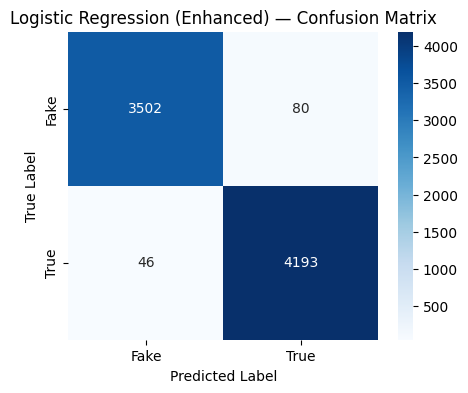

In [110]:
cm = confusion_matrix(y_test_enh, log_reg_enhanced_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("Logistic Regression (Enhanced) — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [111]:
log_reg_enhanced_report = classification_report(y_test_enh, log_reg_enhanced_test_pred, output_dict=True)

results_enhanced.append({
    "Model": "Logistic Regression (Enhanced)",
    "Train Accuracy": log_reg_enhanced_train_acc,
    "Test Accuracy": log_reg_enhanced_test_acc,
    "Precision (Fake)": log_reg_enhanced_report["0"]["precision"],
    "Recall (Fake)": log_reg_enhanced_report["0"]["recall"],
    "F1 (Fake)": log_reg_enhanced_report["0"]["f1-score"],
    "Precision (True)": log_reg_enhanced_report["1"]["precision"],
    "Recall (True)": log_reg_enhanced_report["1"]["recall"],
    "F1 (True)": log_reg_enhanced_report["1"]["f1-score"],
})

Test accuracy actually drops a little against the plain TF-IDF version, 0.9839 here versus 0.9843 without the extra features. The two handcrafted columns get added to 10,000 TF-IDF weights, so their signal is too small to move a linear model that is already this accurate. If anything, this is a case where an engineered feature did not help.

### Random Forest (Enhanced)

In [112]:
rf_enhanced = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_enhanced.fit(X_train_enh, y_train_enh)

RandomForestClassifier(max_depth=10, random_state=42)

In [113]:
rf_enhanced_train_pred = rf_enhanced.predict(X_train_enh)
rf_enhanced_test_pred = rf_enhanced.predict(X_test_enh)

rf_enhanced_train_acc = accuracy_score(y_train_enh, rf_enhanced_train_pred)
rf_enhanced_test_acc = accuracy_score(y_test_enh, rf_enhanced_test_pred)

print(f"Train Accuracy: {rf_enhanced_train_acc:.4f}")
print(f"Test Accuracy: {rf_enhanced_test_acc:.4f}")
print()
print(classification_report(y_test_enh, rf_enhanced_test_pred, target_names=["Fake", "True"]))

Train Accuracy: 0.9842
Test Accuracy: 0.9744

              precision    recall  f1-score   support

        Fake       0.99      0.95      0.97      3582
        True       0.96      0.99      0.98      4239

    accuracy                           0.97      7821
   macro avg       0.98      0.97      0.97      7821
weighted avg       0.97      0.97      0.97      7821



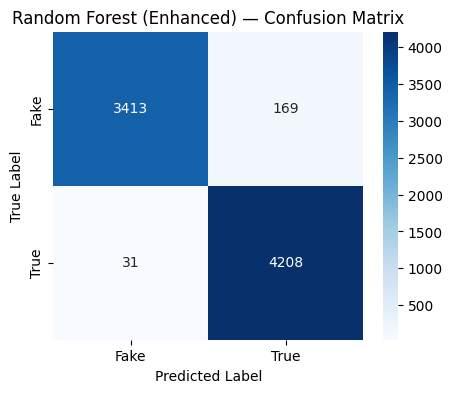

In [114]:
cm = confusion_matrix(y_test_enh, rf_enhanced_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("Random Forest (Enhanced) — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [115]:
rf_enhanced_report = classification_report(y_test_enh, rf_enhanced_test_pred, output_dict=True)

results_enhanced.append({
    "Model": "Random Forest (Enhanced)",
    "Train Accuracy": rf_enhanced_train_acc,
    "Test Accuracy": rf_enhanced_test_acc,
    "Precision (Fake)": rf_enhanced_report["0"]["precision"],
    "Recall (Fake)": rf_enhanced_report["0"]["recall"],
    "F1 (Fake)": rf_enhanced_report["0"]["f1-score"],
    "Precision (True)": rf_enhanced_report["1"]["precision"],
    "Recall (True)": rf_enhanced_report["1"]["recall"],
    "F1 (True)": rf_enhanced_report["1"]["f1-score"],
})

Random Forest moves the other way, 0.9744 test accuracy here against 0.9720 on TF-IDF alone. Unlike Logistic Regression, a tree can split directly on a raw `text_length` or `exclamation_count` value, so it has an actual way to use those two columns instead of just adding them as two more linear weights.

## Normal vs Enhanced Comparison

In [116]:
baseline_subset = [r for r in results_baseline if r["Model"] in ["Logistic Regression", "Random Forest"]]

comparison_df = pd.DataFrame(baseline_subset + results_enhanced)
comparison_df = comparison_df[["Model", "Train Accuracy", "Test Accuracy", "F1 (Fake)", "F1 (True)"]]

comparison_df

,Model,Train Accuracy,Test Accuracy,F1 (Fake),F1 (True)
0,Logistic Regression,0.989451,0.984273,0.982742,0.985555
1,Random Forest,0.981684,0.971998,0.968692,0.974673
2,Logistic Regression (Enhanced),0.989356,0.983890,0.982328,0.985197
3,Random Forest (Enhanced),0.984177,0.974428,0.971534,0.976787


Side by side, Logistic Regression goes from 0.984273 to 0.983890 (essentially flat), and Random Forest goes from 0.971998 to 0.974428 (a real if modest gain). The handcrafted features helped the model that can act on raw numeric values directly, and did nothing for the one that can only weight them linearly. That is a concrete answer to whether engineered features help, instead of just assuming they do.

## Error Analysis: Best Enhanced Model

Accuracy alone hides what the model actually gets wrong. Pulling a few misclassified articles shows whether the errors look like genuinely ambiguous cases or something more systematic. First, print both enhanced models' test accuracy side by side, then use whichever one comes out higher.

In [117]:
print(f"Logistic Regression (Enhanced) test accuracy: {log_reg_enhanced_test_acc:.4f}")
print(f"Random Forest (Enhanced) test accuracy: {rf_enhanced_test_acc:.4f}")

Logistic Regression (Enhanced) test accuracy: 0.9839
Random Forest (Enhanced) test accuracy: 0.9744


Logistic Regression (Enhanced) came out on top above, so it is the model used for the rest of this section. If Random Forest (Enhanced) scores higher when you run this yourself, change `best_model` in the next cell to `rf_enhanced`.

In [118]:
best_model = log_reg_enhanced
best_model_name = "Logistic Regression (Enhanced)"

print(f"Using {best_model_name} for error analysis")

Using Logistic Regression (Enhanced) for error analysis


In [119]:
test_pred_best = best_model.predict(X_test_enh)

original_test_df = df.loc[y_test_enh.index].copy()
original_test_df["predicted_label"] = test_pred_best

false_positives = original_test_df[(original_test_df["label"] == 0) & (original_test_df["predicted_label"] == 1)]
false_negatives = original_test_df[(original_test_df["label"] == 1) & (original_test_df["predicted_label"] == 0)]

print(f"False Positives (actual Fake, predicted True): {len(false_positives)}")
print(f"False Negatives (actual True, predicted Fake): {len(false_negatives)}")

False Positives (actual Fake, predicted True): 80
False Negatives (actual True, predicted Fake): 46


There are 80 false positives against 46 false negatives. In fake news detection these two errors are not equally costly. A false negative lets real misinformation reach a reader unlabeled, where it can shape a real decision or belief. A false positive just wrongly flags a real article, which a human reviewer can catch and correct. By that standard, this model leans toward the safer failure mode, flagging more real news as fake rather than letting fake news through as real, even though the raw false positive count is larger.

In [120]:
print("--- Sample False Positives ---")
for i, row in false_positives.head(3).iterrows():
    print(f"\nIndex {i} | Actual: Fake | Predicted: True")
    print(row["content"][:300], "...")

print("\n--- Sample False Negatives ---")
for i, row in false_negatives.head(3).iterrows():
    print(f"\nIndex {i} | Actual: True | Predicted: Fake")
    print(row["content"][:300], "...")

--- Sample False Positives ---

Index 22109 | Actual: Fake | Predicted: True
TRUMP ADVISOR Has Warning For Syria That Has Saved Lives [Video] Deputy Assistant to the President Sebastian Gorka warned Syrian President Bashar Assad after evidence arose earlier this week that the Assad regime could be planning another chemical weapons attack on its people. Gorka says,  if you do ...

Index 16129 | Actual: Fake | Predicted: True
BREAKING: NORTH KOREA Detains American Student For “Hostile Act” Apparently it takes just one American student to destroy the unity in North Korea:North Korea has detained a U.S. university student, the third western citizen known to be held in the isolated state, for committing a  hostile act  and  ...

Index 38309 | Actual: Fake | Predicted: True
SCRUBBED CLEAN? HILLARY CLINTON TO FINALLY TURN OVER SERVER TO FBI I appears that Hillary Clinton is really in a big mess with this e-mail scandal. She could have just turned the server over and dealt with this at the beg

The three false positives above (Trump-Syria, North Korea detention, Clinton server) share a plain, attribution-heavy reporting tone despite ALL-CAPS headlines, which is likely what convinced the model to call them True. The false negatives are more surprising. All three are genuinely Reuters wire pieces, and one even has "(Reuters)" directly in the text, but two of the three center on criticism of Trump. That overlaps with the sharper, opinionated language the model associates with Fake, which may be enough to pull a correctly-sourced article toward a wrong prediction.

## Custom Prediction: All Models

In [121]:
custom_news = """
New Study Reveals That Eating Chocolate While Listening To Mozart Makes You 45% Smarter. Scientists are astounded by the results, urging everyone to adopt this new regimen immediately. This groundbreaking research was published in a highly reputable, peer-reviewed journal.
"""

In [122]:
processed_custom = custom_news.lower()
processed_custom = re.sub(r"http\S+|www\S+", " url ", processed_custom)
processed_custom = re.sub(r"<.*?>", " ", processed_custom)
processed_custom = processed_custom.translate(str.maketrans("", "", string.punctuation))
processed_custom = re.sub(r"\s+", " ", processed_custom).strip()

custom_tokens = word_tokenize(processed_custom)
custom_tokens = [word for word in custom_tokens if word not in stopwords_set]
custom_tokens = [stemmer.stem(word) for word in custom_tokens]

processed_custom = " ".join(custom_tokens)
print(processed_custom)

new studi reveal eat chocol listen mozart make 45 smarter scientist astound result urg everyon adopt new regimen immedi groundbreak research publish highli reput peerreview journal


In [123]:
X_custom_tfidf = tfidf_vectorizer.transform([processed_custom])

custom_exclamation = custom_news.count("!")
custom_length = len(custom_news)
X_custom_enhanced = hstack([X_custom_tfidf, [[custom_exclamation, custom_length]]])

In [124]:
label_map = {0: "Fake", 1: "True"}

print("Baseline models (TF-IDF only):")

knn_pred = knn_model.predict(X_custom_tfidf)[0]
print(f"  KNN                  -> {label_map[knn_pred]}")

log_reg_pred = log_reg_model.predict(X_custom_tfidf)[0]
print(f"  Logistic Regression  -> {label_map[log_reg_pred]}")

rf_pred = rf_model.predict(X_custom_tfidf)[0]
print(f"  Random Forest        -> {label_map[rf_pred]}")

nn_pred = nn_model.predict(X_custom_tfidf)[0]
print(f"  Neural Network       -> {label_map[nn_pred]}")

Baseline models (TF-IDF only):
  KNN                  -> Fake
  Logistic Regression  -> Fake
  Random Forest        -> Fake
  Neural Network       -> Fake


In [125]:
print("Enhanced models (TF-IDF + handcrafted features):")

log_reg_enh_pred = log_reg_enhanced.predict(X_custom_enhanced)[0]
print(f"  Logistic Regression (Enhanced) -> {label_map[log_reg_enh_pred]}")

rf_enh_pred = rf_enhanced.predict(X_custom_enhanced)[0]
print(f"  Random Forest (Enhanced)       -> {label_map[rf_enh_pred]}")

Enhanced models (TF-IDF + handcrafted features):
  Logistic Regression (Enhanced) -> Fake
  Random Forest (Enhanced)       -> True


Every model agrees the chocolate-and-Mozart article is Fake, except Random Forest (Enhanced), which alone predicts True. That model leans partly on `exclamation_count` and `text_length`, and this snippet has zero exclamation marks and fairly ordinary length, so it has less to work with on the two features it was built to use. One example proves nothing statistically, but it is a clean illustration of why comparing several models beats trusting any single one.

In [126]:
# from google.colab import files

# # Download the CSV file
# files.download('Raw_Dataset.csv')


In [127]:
# files.download('processed_news_dataset.csv')